# 📈 Semana 3: Correlación, Supuestos Estadísticos e Hipótesis

## Objetivos
- Analizar correlaciones entre variables (Pearson, Spearman, Kendall)
- Comprender y evaluar homoscedasticidad y heteroscedasticidad
- Detectar multicolinealidad con VIF
- Formular preguntas de investigación e hipótesis
- Realizar pruebas de hipótesis estadísticas

## Dataset: Water Quality (Calidad del Agua)
Continuamos con el dataset limpio y preparado de la Semana 2.

In [ ]:

# =============================================================================
# CONCEPTO: Importación de librerías para análisis estadístico avanzado
# -----------------------------------------------------------------------------
# Se importan las librerías necesarias para el análisis de correlación,
# supuestos estadísticos y pruebas de hipótesis:
#
# pandas / numpy:
#   → Manipulación de datos y operaciones numéricas vectorizadas.
#
# matplotlib / seaborn:
#   → Visualizaciones estáticas: heatmaps, histogramas, boxplots, barras.
#   → seaborn complementa matplotlib con gráficos estadísticos de alto nivel.
#
# plotly.express:
#   → Gráficos interactivos (no se usa intensivamente en este notebook,
#     pero disponible para visualizaciones complementarias).
#
# scipy.stats:
#   → Módulo central para estadística inferencial:
#       pearsonr()   → correlación de Pearson + p-valor
#       spearmanr()  → correlación de Spearman + p-valor
#       kendalltau() → correlación de Kendall + p-valor
#       ttest_ind()  → prueba t de Student para muestras independientes
#       f_oneway()   → ANOVA de un factor
#
# plt.style.use('seaborn-v0_8-whitegrid'):
#   → Aplica un tema visual limpio con cuadrícula para todos los gráficos.
#   → 'seaborn-v0_8-whitegrid' es la versión compatible con matplotlib ≥3.6.
#
# pd.set_option('display.max_columns', None):
#   → Muestra todas las columnas en los DataFrames sin truncar.
#
# CRITERIO DE USO: Centralizar todas las importaciones al inicio del notebook
# facilita la reproducibilidad y la identificación rápida de dependencias.
# =============================================================================

# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from scipy.stats import pearsonr, spearmanr, kendalltau
import warnings
warnings.filterwarnings('ignore')

# Configuración
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

print("✅ Librerías importadas")


✅ Librerías importadas


In [ ]:

# =============================================================================
# CONCEPTO: Carga y limpieza del dataset — pipeline reproducible entre semanas
# -----------------------------------------------------------------------------
# Se replica el mismo pipeline de preparación de datos de semanas anteriores
# para garantizar que el análisis comience con un dataset limpio y coherente.
#
# pd.read_csv(url):
#   → Carga directamente desde GitHub (URL raw) para máxima portabilidad.
#   → No requiere tener el archivo localmente si hay conexión a internet.
#
# Imputación con mediana por columna:
#   → Se usa la MEDIANA (no la media) para imputar datos faltantes:
#       · La mediana es robusta frente a outliers.
#       · Para variables con distribución asimétrica, la mediana es más
#         representativa del valor típico que la media.
#   → df[col].fillna(df[col].median(), inplace=True): reemplaza NaN con
#     la mediana de esa columna calculada solo sobre valores no nulos.
#
# .drop_duplicates().reset_index(drop=True):
#   → Elimina filas con valores idénticos en todas las columnas.
#   → reset_index() reestablece el índice secuencial 0, 1, 2, ...
#     evitando gaps en el índice (drop=True: no crea columna con el índice antiguo).
#
# cols_numericas:
#   → Lista de columnas numéricas excluyendo la variable objetivo 'Potability'.
#   → Se usa en todas las operaciones posteriores (correlación, ANOVA, VIF).
#   → La exclusión evita que la variable objetivo interfiera en el cálculo
#     de correlaciones entre predictoras.
#
# CRITERIO DE USO: Usar esta celda de carga/limpieza como primer bloque
# ejecutable del notebook y documentar explícitamente cada paso de
# transformación para garantizar trazabilidad.
# =============================================================================

# Carga y limpieza del dataset (replicando pasos de la Semana 2)
url = "https://raw.githubusercontent.com/jaquimbayoc7/material-fundamentos_datos/main/data/water_potability.csv"
df = pd.read_csv(url)

# Imputar valores faltantes con la mediana de cada columna
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Eliminar duplicados y resetear índice
df = df.drop_duplicates().reset_index(drop=True)

# Variables predictoras (excluir la variable objetivo Potability)
cols_numericas = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'Potability']

print(f"✅ Dataset limpio: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Variables predictoras: {cols_numericas}")
df.head()


✅ Dataset limpio: 3276 filas x 10 columnas
Variables predictoras: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.036752,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.073546,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.073546,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


---
# 1. Análisis de Correlación

La **correlación** mide la fuerza y dirección de la relación **lineal** entre dos variables. Los valores van de -1 a +1:

| Rango | Interpretación |
|-------|----------------|
| 0.00 - 0.19 | Muy débil |
| 0.20 - 0.39 | Débil |
| 0.40 - 0.59 | Moderada |
| 0.60 - 0.79 | Fuerte |
| 0.80 - 1.00 | Muy fuerte |

### Tipos de coeficientes:
- **Pearson (r)**: Mide relación lineal. Asume distribución normal.
- **Spearman (ρ)**: Mide relación monótona. No asume normalidad. Basado en rangos.
- **Kendall (τ)**: Similar a Spearman pero más robusto con muestras pequeñas.

📊 CORRELACIÓN DE PEARSON


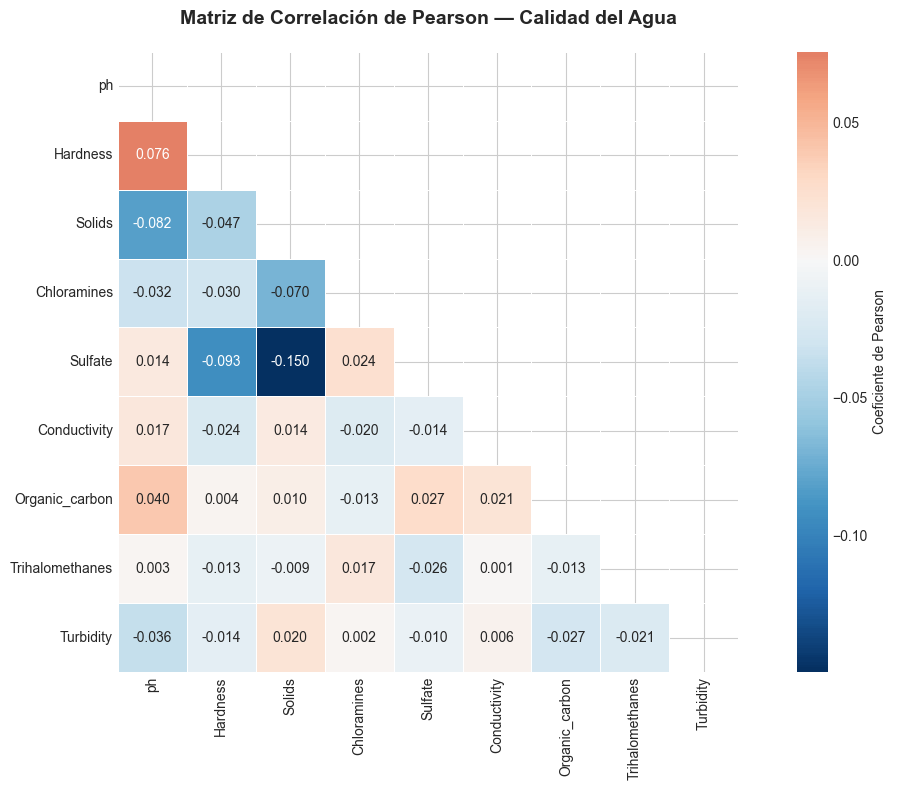

In [ ]:

# =============================================================================
# CONCEPTO: Correlación de Pearson — matriz de correlación lineal
# -----------------------------------------------------------------------------
# El coeficiente de Pearson (r) mide la fuerza y dirección de la relación
# LINEAL entre dos variables continuas.
#
# df[cols_numericas].corr(method='pearson'):
#   → Calcula la matriz de correlación de todas las pares de variables.
#   → Cada celda [i, j] contiene el coeficiente r entre la variable i y j.
#   → La diagonal siempre es 1.0 (cada variable correlaciona perfectamente
#     consigo misma).
#   → Resultado: DataFrame n×n simétrico.
#
# np.triu(np.ones_like(corr, dtype=bool)):
#   → Crea una máscara triangular superior (True en la mitad superior).
#   → mask=mask en sns.heatmap: oculta la mitad superior (duplicada)
#     y la diagonal → muestra solo el triángulo inferior.
#
# sns.heatmap() parámetros clave:
#   annot=True   → escribe el valor numérico dentro de cada celda.
#   fmt='.3f'    → 3 decimales.
#   cmap='RdBu_r'→ divergente: azul (correlación positiva), rojo (negativa).
#   center=0     → asegura que el color neutro coincide con r=0.
#   square=True  → celdas cuadradas para mayor legibilidad.
#   linewidths   → bordes entre celdas.
#
# SUPUESTOS DE PEARSON:
#   ✔ Relación lineal entre variables.
#   ✔ Variables continuas.
#   ✔ Distribución aproximadamente normal.
#   ✔ Sin outliers extremos (son sensibles a ellos).
#
# CRITERIO DE USO: Usar Pearson cuando se cumplen los supuestos de normalidad
# y la relación esperada es lineal. Si hay outliers o distribución no normal,
# preferir Spearman.
# =============================================================================

print("📊 CORRELACIÓN DE PEARSON")
print("=" * 50)

corr_pearson = df[cols_numericas].corr(method='pearson')

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))
sns.heatmap(corr_pearson, annot=True, cmap='RdBu_r', fmt='.3f',
            mask=mask, center=0, square=True, linewidths=0.5,
            cbar_kws={'label': 'Coeficiente de Pearson'})
plt.title('Matriz de Correlación de Pearson — Calidad del Agua',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


📊 CORRELACIÓN DE SPEARMAN


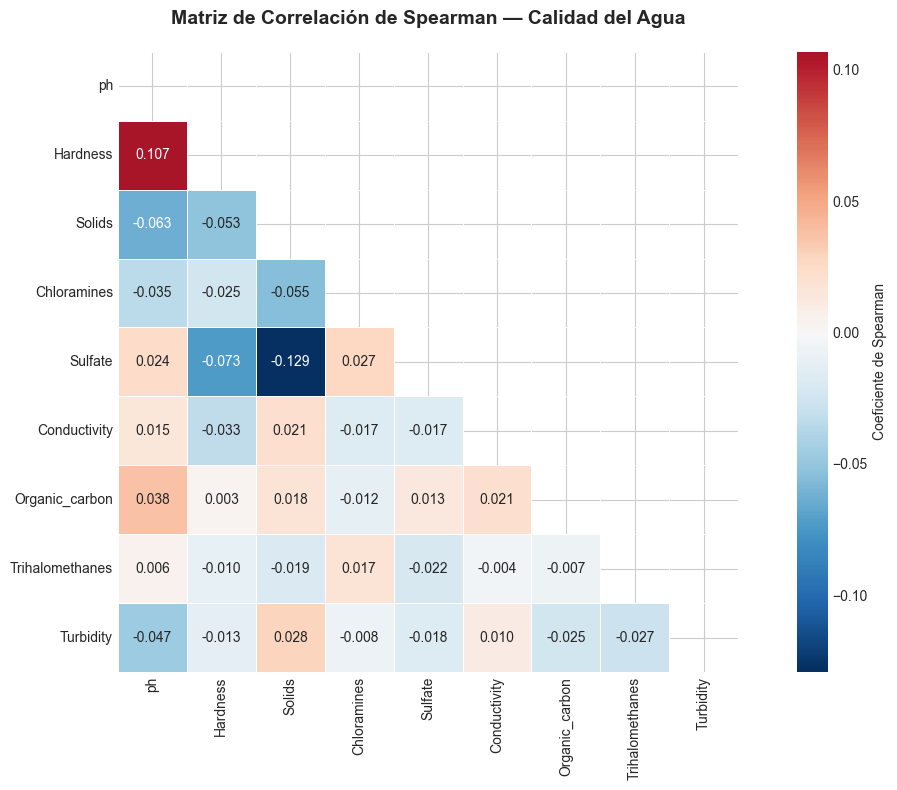

In [ ]:

# =============================================================================
# CONCEPTO: Correlación de Spearman — correlación de rangos (no paramétrica)
# -----------------------------------------------------------------------------
# El coeficiente de Spearman (ρ, "rho") mide la fuerza y dirección de la
# relación MONÓTONA entre dos variables, sin asumir linealidad ni normalidad.
#
# CÓMO FUNCIONA:
#   1. Convierte cada variable a rangos (el menor valor → rango 1, etc.).
#   2. Calcula el coeficiente de Pearson sobre los rangos.
#   → Resultado: ρ entre -1 y +1, con igual interpretación que Pearson.
#
# method='spearman' en .corr():
#   → Pandas aplica automáticamente la transformación de rangos antes de
#     calcular la correlación.
#
# DIFERENCIA CLAVE vs PEARSON:
#   Pearson:  sensible a outliers y asume linealidad.
#   Spearman: robusto a outliers, captura relaciones monótonas no lineales.
#             (funciona si "cuando X sube, Y tiende a subir/bajar",
#              aunque no sea de forma exactamente proporcional).
#
# INTERPRETACIÓN DE DIFERENCIAS ENTRE MATRICES:
#   Si Spearman >> Pearson: la relación es monótona pero NO lineal.
#   Si Spearman ≈ Pearson:  la relación es aproximadamente lineal.
#   Si ambos ≈ 0:           no hay relación sistemática.
#
# CRITERIO DE USO: Preferir Spearman cuando:
#   - Las variables tienen distribución asimétrica o no normal.
#   - Hay outliers que podrían distorsionar Pearson.
#   - Se sospecha una relación monótona pero no necesariamente lineal.
# =============================================================================

print("📊 CORRELACIÓN DE SPEARMAN")
print("=" * 50)

corr_spearman = df[cols_numericas].corr(method='spearman')

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))
sns.heatmap(corr_spearman, annot=True, cmap='RdBu_r', fmt='.3f',
            mask=mask, center=0, square=True, linewidths=0.5,
            cbar_kws={'label': 'Coeficiente de Spearman'})
plt.title('Matriz de Correlación de Spearman — Calidad del Agua',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


📊 CORRELACIÓN DE KENDALL


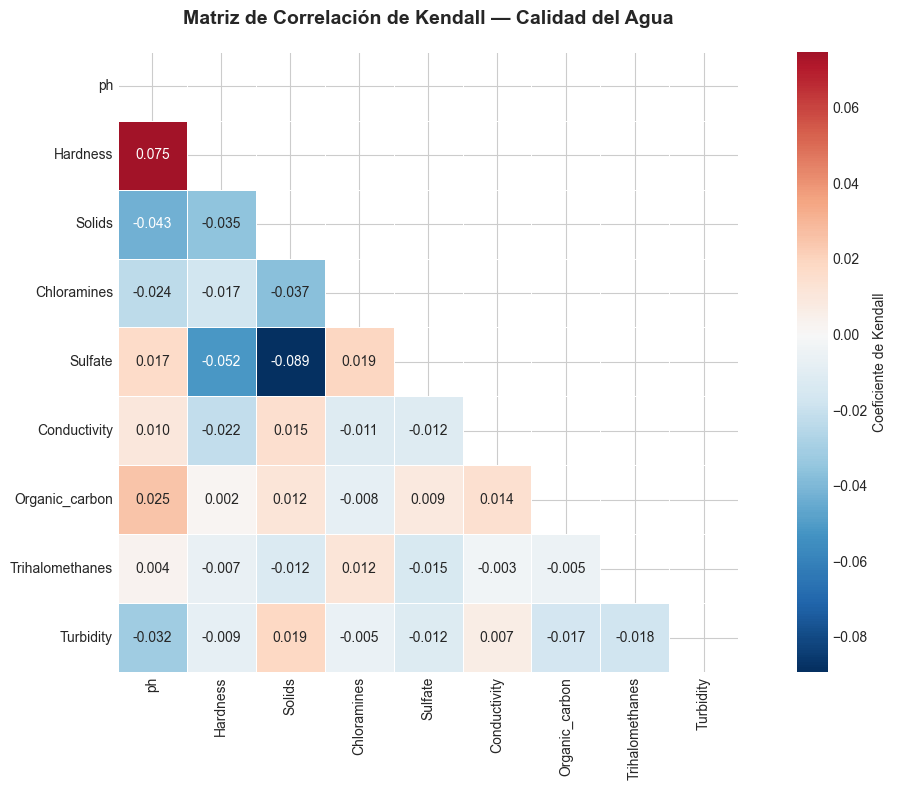

In [ ]:

# =============================================================================
# CONCEPTO: Correlación de Kendall — coeficiente tau (τ) de concordancia
# -----------------------------------------------------------------------------
# El coeficiente de Kendall (τ, "tau") mide la similitud en el ORDEN de
# rangos entre dos variables, contando pares concordantes y discordantes.
#
# CÓMO FUNCIONA:
#   Para cada par de observaciones (i, j):
#     → Par CONCORDANTE: si X_i > X_j entonces Y_i > Y_j (mismo orden).
#     → Par DISCORDANTE: si X_i > X_j entonces Y_i < Y_j (orden invertido).
#   τ = (concordantes - discordantes) / total de pares posibles
#
# DIFERENCIA vs SPEARMAN:
#   Spearman: transforma a rangos y aplica Pearson → sensible a distancias.
#   Kendall:  solo cuenta concordancias → más robusto con empates y outliers.
#   → Kendall tiene valores absolutos menores que Spearman pero es más
#     interpretable directamente: τ=0.6 significa que el 80% de los pares
#     [(60%+1)/2 * 100] tienen el mismo orden en ambas variables.
#
# CUÁNDO ES PREFERIBLE KENDALL:
#   - Muestras pequeñas (n < 30): estadísticamente más fiable.
#   - Datos con muchos empates.
#   - Se prefiere una interpretación probabilística (proporción de pares
#     concordantes vs discordantes).
#
# COMPARACIÓN DE LAS 3 MATRICES:
#   Si Pearson ≈ Spearman ≈ Kendall → relación lineal robusta.
#   Si solo Pearson es alto → posible influencia de outliers.
#   Si Spearman ≈ Kendall pero >> Pearson → relación monótona no lineal.
#
# CRITERIO DE USO: Usar Kendall como validación adicional de Spearman,
# especialmente en muestras pequeñas o con datos ordinales.
# =============================================================================

print("📊 CORRELACIÓN DE KENDALL")
print("=" * 50)

corr_kendall = df[cols_numericas].corr(method='kendall')

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_kendall, dtype=bool))
sns.heatmap(corr_kendall, annot=True, cmap='RdBu_r', fmt='.3f',
            mask=mask, center=0, square=True, linewidths=0.5,
            cbar_kws={'label': 'Coeficiente de Kendall'})
plt.title('Matriz de Correlación de Kendall — Calidad del Agua',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


In [ ]:

# =============================================================================
# CONCEPTO: Comparación cuantitativa de los 3 métodos de correlación
# -----------------------------------------------------------------------------
# Calcular los 3 coeficientes para pares específicos permite identificar
# directamente qué tipo de relación existe entre cada par de variables.
#
# pares = [...]:
#   → Lista de tuplas con pares de variables seleccionadas por su
#     relevancia temática (química del agua) o por mostrar correlaciones
#     interesantes en las matrices previas.
#
# pearsonr(x, y) → (r, p_valor):
#   → Devuelve el coeficiente r Y el p-valor de la prueba bilateral H₀: r=0.
#   → Se captura solo r con r_p, _ (el _ descarta el p-valor en esta tabla).
#
# spearmanr(x, y) → (rho, p_valor):
#   → Misma estructura que pearsonr.
#
# kendalltau(x, y) → (tau, p_valor):
#   → Misma estructura.
#
# PATRÓN DE INTERPRETACIÓN:
#   Si |Pearson| >> |Spearman|: outliers inflando la correlación lineal.
#   Si |Spearman| > |Pearson|:  relación monótona no lineal o asimetría.
#   Si los 3 son similares:     relación lineal robusta.
#   Si los 3 son cercanos a 0:  no hay relación sistemática.
#
# CRITERIO DE USO: Esta tabla es útil para comunicar el análisis de
# correlación de forma concisa en un informe, mostrando los 3 métodos
# lado a lado para comparación directa.
# =============================================================================

print("📊 COMPARACIÓN DE MÉTODOS DE CORRELACIÓN")
print("=" * 60)

# Pares seleccionados por relevancia temática
pares = [
    ('ph', 'Hardness'),
    ('Solids', 'Conductivity'),
    ('Organic_carbon', 'Trihalomethanes'),
    ('Hardness', 'Sulfate')
]

print(f"{'Par de Variables':35s} {'Pearson':>10s} {'Spearman':>10s} {'Kendall':>10s}")
print("-" * 70)

for var1, var2 in pares:
    r_p, _ = pearsonr(df[var1], df[var2])      # r de Pearson (se descarta el p-valor)
    r_s, _ = spearmanr(df[var1], df[var2])     # ρ de Spearman
    r_k, _ = kendalltau(df[var1], df[var2])    # τ de Kendall
    print(f"{var1} vs {var2:20s} {r_p:+10.4f} {r_s:+10.4f} {r_k:+10.4f}")


📊 COMPARACIÓN DE MÉTODOS DE CORRELACIÓN
Par de Variables                       Pearson   Spearman    Kendall
----------------------------------------------------------------------
ph vs Hardness                +0.0758    +0.1069    +0.0749
Solids vs Conductivity            +0.0138    +0.0211    +0.0147
Organic_carbon vs Trihalomethanes         -0.0130    -0.0073    -0.0049
Hardness vs Sulfate                 -0.0928    -0.0735    -0.0519


🎯 CORRELACIÓN CON LA VARIABLE OBJETIVO (Potability)


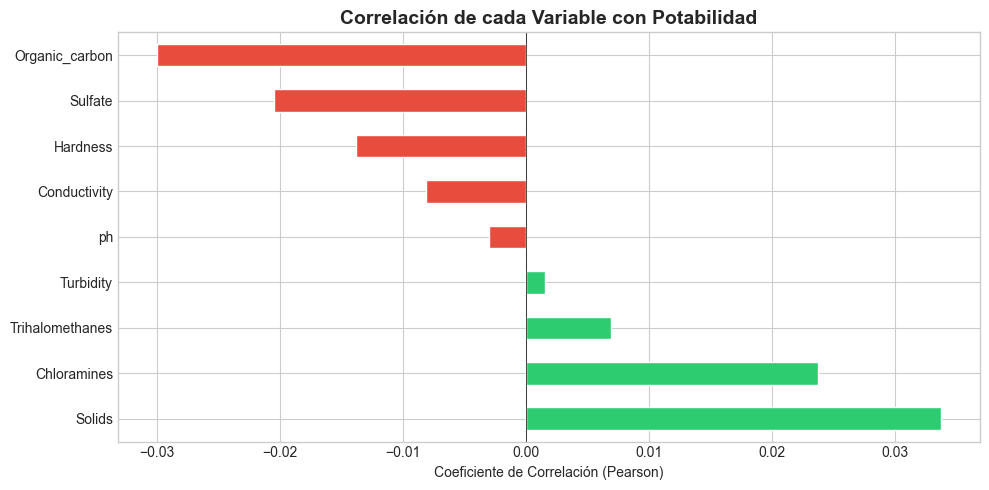

In [ ]:

# =============================================================================
# CONCEPTO: Correlación de cada predictora con la variable objetivo
# -----------------------------------------------------------------------------
# Calcular la correlación de cada variable con la variable a predecir
# (Potability) es uno de los primeros pasos del análisis de features en ML.
# Indica qué variables tienen más "señal" respecto al target.
#
# df[cols_numericas + ['Potability']].corr()['Potability']:
#   → Calcula la matriz completa y extrae solo la columna 'Potability'.
#   → Resultado: Serie con el coeficiente de Pearson de cada variable
#     respecto a Potability.
#
# .drop('Potability'):
#   → Elimina la autocorrelación (Potability vs Potability = 1.0) que
#     no aporta información.
#
# .sort_values(ascending=False):
#   → Ordena de mayor a menor correlación para mostrar las más relevantes
#     primero.
#
# colores = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_target.values]:
#   → Color verde para correlación positiva (cuando sube la variable,
#     Potability tiende a ser mayor → más potable).
#   → Color rojo para correlación negativa (cuando sube la variable,
#     Potability tiende a ser menor → menos potable).
#
# .plot(kind='barh'):
#   → Barras horizontales, más legible cuando los nombres de variables
#     son largos.
#
# plt.axvline(x=0): referencia visual en correlación = 0.
#
# LIMITACIÓN IMPORTANTE:
#   Potability es una variable binaria (0/1), no continua. Pearson no es
#   ideal para correlaciones con variables binarias → la correlación puntual
#   biserial (equivalente) puede ser más apropiada. Esta visualización es
#   exploratoria y no reemplaza un análisis de clasificación.
#
# CRITERIO DE USO: Usar como primer filtro para selección de features.
# Variables con |correlación| muy baja pueden ser candidatas a descarte,
# aunque hay que complementar con pruebas formales como ANOVA.
# =============================================================================

# Correlación con la variable objetivo (Potability)
print("🎯 CORRELACIÓN CON LA VARIABLE OBJETIVO (Potability)")
print("=" * 55)

corr_target = df[cols_numericas + ['Potability']].corr()['Potability'].drop('Potability').sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colores = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_target.values]
corr_target.plot(kind='barh', color=colores, edgecolor='white')
plt.xlabel('Coeficiente de Correlación (Pearson)')
plt.title('Correlación de cada Variable con Potabilidad', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()


---
# 2. Homoscedasticidad y Heteroscedasticidad

## Definiciones

- **Homoscedasticidad**: La varianza de los errores (residuos) es **constante** a lo largo de todos los valores de la variable predictora. Es un **supuesto clave** de la regresión lineal.

- **Heteroscedasticidad**: La varianza de los errores **NO es constante** — varía con los valores de la variable predictora. Esto viola el supuesto de regresión y puede producir:
  - Estimadores sesgados de los errores estándar
  - Intervalos de confianza incorrectos
  - Pruebas de hipótesis poco fiables

📊 ANÁLISIS VISUAL DE RESIDUOS


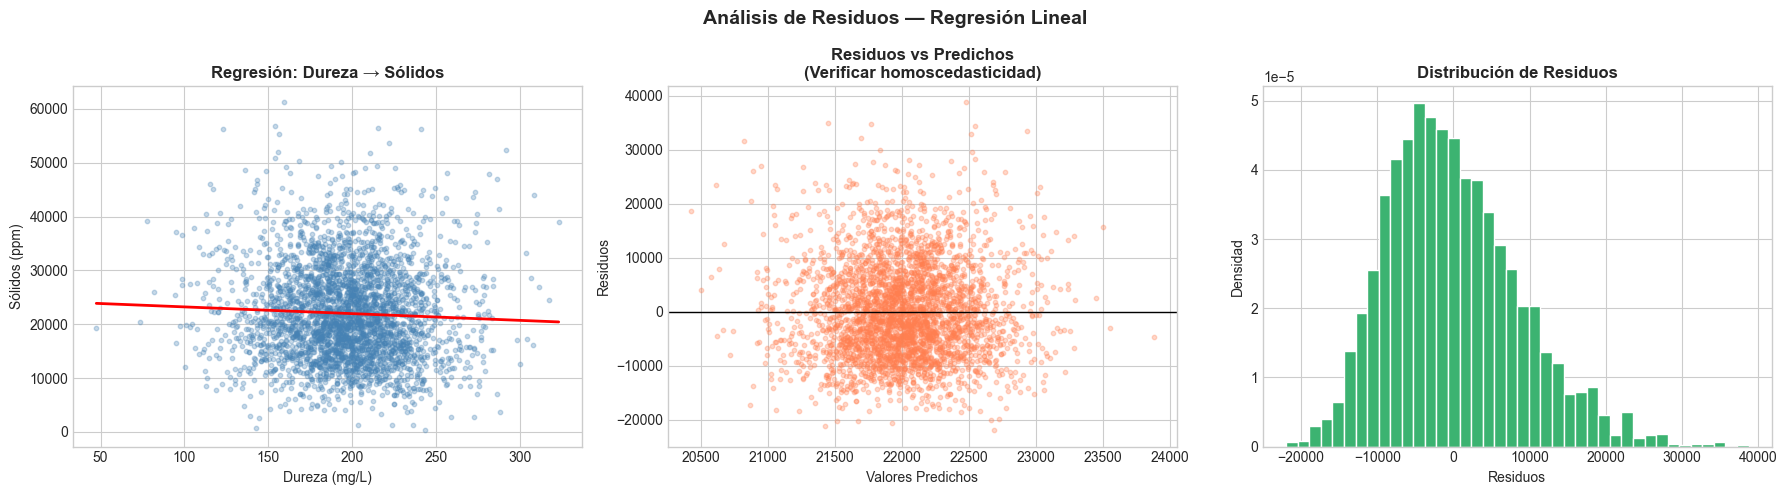


💡 Si los residuos muestran un patrón de 'embudo' (se amplían o estrechan),
   hay HETEROSCEDASTICIDAD. Si son uniformes, hay HOMOSCEDASTICIDAD.


In [ ]:

# =============================================================================
# CONCEPTO: Análisis visual de homoscedasticidad mediante gráfico de residuos
# -----------------------------------------------------------------------------
# La homoscedasticidad es el supuesto de que la VARIANZA de los residuos
# del modelo es constante para todos los niveles de la variable predictora.
# Se evalúa visualmente antes de aplicar pruebas formales.
#
# from sklearn.linear_model import LinearRegression:
#   → Ajusta un modelo y=a+bx para obtener los residuos predichos.
#
# from statsmodels: se importarán en esta y celdas siguientes para
#   pruebas formales de heteroscedasticidad (Breusch-Pagan, etc.).
#
# LinearRegression().fit(X, y) → modelo:
#   → Ajusta el modelo de regresión OLS: Hardness → Solids.
#   → .predict(X) devuelve los valores ajustados ŷ.
#
# residuos = y - y_pred:
#   → Residuo = diferencia entre el valor real y el valor predicho.
#   → Si el modelo es correcto, los residuos deben ser ruido aleatorio.
#
# GRÁFICOS DE DIAGNÓSTICO:
#
# 1. Scatter con línea de regresión:
#    → Muestra la relación entre X e Y y la recta ajustada.
#    → Si hay heterocedasticidad visible, la dispersión cambia a lo largo
#      de la recta (se ensancha o estrecha).
#
# 2. Residuos vs Valores predichos (GRÁFICO CLAVE):
#    → EJE X: valores ajustados (ŷ).
#    → EJE Y: residuos (y - ŷ).
#    → PATRÓN ESPERADO (homosc.): nube aleatoria centrada en y=0, sin forma.
#    → PATRÓN "EMBUDO": la dispersión aumenta con el valor predicho → heterosc.
#    → axhline(y=0): referencia horizontal para identificar el centro.
#
# 3. Histograma de residuos:
#    → Los residuos deberían distribución aproximadamente normal.
#    → Si están muy sesgados o tienen colas pesadas → viola el supuesto.
#
# CRITERIO DE USO: Siempre generar el gráfico de residuos vs predichos
# ANTES de interpretar los coeficientes de un modelo de regresión lineal.
# Es la primera verificación de supuestos.
# =============================================================================

from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, het_goldfeldquandt

print("📊 ANÁLISIS VISUAL DE RESIDUOS")
print("=" * 50)

# Ajustar modelo de regresión simple: Hardness (predictora) → Solids (respuesta)
X = df[['Hardness']].values
y = df['Solids'].values

modelo = LinearRegression()
modelo.fit(X, y)
y_pred = modelo.predict(X)
residuos = y - y_pred    # residuos = error del modelo en cada observación

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Scatter con línea de regresión
axes[0].scatter(X, y, alpha=0.3, s=10, color='steelblue')
axes[0].plot(np.sort(X, axis=0), modelo.predict(np.sort(X, axis=0)), color='red', linewidth=2)
axes[0].set_xlabel('Dureza (mg/L)')
axes[0].set_ylabel('Sólidos (ppm)')
axes[0].set_title('Regresión: Dureza → Sólidos', fontweight='bold')

# 2. Residuos vs Valores predichos — buscamos nube aleatoria (sin patrón de embudo)
axes[1].scatter(y_pred, residuos, alpha=0.3, s=10, color='coral')
axes[1].axhline(y=0, color='black', linewidth=1)    # referencia en residuo=0
axes[1].set_xlabel('Valores Predichos')
axes[1].set_ylabel('Residuos')
axes[1].set_title('Residuos vs Predichos\n(Verificar homoscedasticidad)', fontweight='bold')

# 3. Distribución de residuos — buscamos forma aproximadamente normal
axes[2].hist(residuos, bins=40, color='mediumseagreen', edgecolor='white', density=True)
axes[2].set_xlabel('Residuos')
axes[2].set_ylabel('Densidad')
axes[2].set_title('Distribución de Residuos', fontweight='bold')

plt.suptitle('Análisis de Residuos — Regresión Lineal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Si los residuos muestran un patrón de 'embudo' (se amplían o estrechan),")
print("   hay HETEROSCEDASTICIDAD. Si son uniformes, hay HOMOSCEDASTICIDAD.")


In [ ]:

# =============================================================================
# CONCEPTO: Pruebas formales de heteroscedasticidad (Breusch-Pagan y Goldfeld-Quandt)
# -----------------------------------------------------------------------------
# El análisis visual es subjetivo. Las pruebas formales proveen un criterio
# estadístico objetivo para decidir si hay heteroscedasticidad.
#
# sm.add_constant(X):
#   → Agrega una columna de unos al DataFrame de predictoras.
#   → Necesario para que statsmodels incluya el intercepto (β₀) en el modelo.
#   → Sin esto, el modelo pasa por el origen (β₀=0), lo cual es incorrecto.
#
# sm.OLS(y, X_sm).fit():
#   → Ajusta un modelo de Mínimos Cuadrados Ordinarios (OLS) con statsmodels.
#   → .fit() devuelve un objeto con residuos, coeficientes, R², etc.
#   → Se usa statsmodels en lugar de sklearn porque provee los residuos
#     en formato compatible con las pruebas de heteroscedasticidad.
#
# ─── PRUEBA DE BREUSCH-PAGAN ──────────────────────────────────────────────
# Hipótesis:
#   H₀: La varianza de los errores es constante (homoscedasticidad).
#   H₁: La varianza de los errores depende de las predictoras.
# Procedimiento: Regresión auxiliar de los residuos² sobre las predictoras.
# het_breuschpagan(residuos, X) → (LM_stat, p_valor, F_stat, F_p_valor)
#   → Si p < 0.05: rechazar H₀ → hay heteroscedasticidad.
#
# ─── PRUEBA DE GOLDFELD-QUANDT ──────────────────────────────────────────────
# Hipótesis: igual que Breusch-Pagan.
# Procedimiento: Divide la muestra en dos mitades (valores bajos y altos
#   de X) y compara la varianza de los residuos entre ambas mitades.
# het_goldfeldquandt(residuos, X) → (F_stat, p_valor, alternativa)
#   → Si p < 0.05: hay más varianza en una mitad → heterocedasticidad.
#
# DIFERENCIA ENTRE PRUEBAS:
#   Breusch-Pagan: más general (detecta cualquier forma de heterosc.).
#   Goldfeld-Quandt: más potente cuando la varianza aumenta/disminuye
#     monótonamente con X (patrón de embudo).
#
# CRITERIO DE USO: Aplicar ambas pruebas y reportar la conclusión conjunta.
# Si ambas coinciden, la evidencia es más sólida.
# =============================================================================

print("🧪 PRUEBAS DE HETEROSCEDASTICIDAD")
print("=" * 55)

# Ajuste con statsmodels para obtener residuos formales (incluye intercepto)
X_sm = sm.add_constant(df['Hardness'])
modelo_sm = sm.OLS(df['Solids'], X_sm).fit()

# ── Prueba de Breusch-Pagan ──
print("\n📋 Prueba de Breusch-Pagan")
print("-" * 40)
bp_stat, bp_pvalue, bp_fstat, bp_fpvalue = het_breuschpagan(modelo_sm.resid, X_sm)
print(f"  Estadístico LM: {bp_stat:.4f}")
print(f"  p-valor:        {bp_pvalue:.6f}")
print(f"  Conclusión:     {'❌ HAY heteroscedasticidad' if bp_pvalue < 0.05 else '✅ Homoscedasticidad (no se rechaza H₀)'}")

# ── Prueba de Goldfeld-Quandt ──
print("\n📋 Prueba de Goldfeld-Quandt")
print("-" * 40)
gq_stat, gq_pvalue, gq_order = het_goldfeldquandt(modelo_sm.resid, X_sm)
print(f"  Estadístico F:  {gq_stat:.4f}")
print(f"  p-valor:        {gq_pvalue:.6f}")
print(f"  Conclusión:     {'❌ HAY heteroscedasticidad' if gq_pvalue < 0.05 else '✅ Homoscedasticidad (no se rechaza H₀)'}")

print("\n💡 Regla: Si p-valor < 0.05 → Se rechaza H₀ (homoscedasticidad) → Hay heteroscedasticidad")


🧪 PRUEBAS DE HETEROSCEDASTICIDAD

📋 Prueba de Breusch-Pagan
----------------------------------------
  Estadístico LM: 0.4701
  p-valor:        0.492948
  Conclusión:     ✅ Homoscedasticidad (no se rechaza H₀)

📋 Prueba de Goldfeld-Quandt
----------------------------------------
  Estadístico F:  0.8784
  p-valor:        0.995599
  Conclusión:     ✅ Homoscedasticidad (no se rechaza H₀)

💡 Regla: Si p-valor < 0.05 → Se rechaza H₀ (homoscedasticidad) → Hay heteroscedasticidad


In [ ]:

# =============================================================================
# CONCEPTO: Diagnóstico sistemático de heteroscedasticidad para todos los pares
# -----------------------------------------------------------------------------
# En lugar de evaluar solo un par de variables, se aplica la prueba de
# Breusch-Pagan a TODAS las combinaciones predictora → respuesta del dataset,
# generando un diagnóstico completo.
#
# Estructura del loop doble:
#   → Itera sobre todos los pares (pred, resp) donde pred ≠ resp.
#   → Para cada par: ajusta OLS y aplica Breusch-Pagan.
#   → Almacena resultados en una lista de diccionarios → pd.DataFrame.
#
# sm.add_constant(df[pred]):
#   → Modelo simple con una sola predictora + intercepto.
#   → No es necesario usar múltiples predictoras aquí porque se evalúa
#     la heterocedasticidad en la relación bivariada.
#
# het_breuschpagan(modelo.resid, X_temp) → (LM, p, F, Fp):
#   → Se usa _ para descartar estadísticos que no se reportan en la tabla.
#
# Columna 'Resultado':
#   → Clasifica cada par en 'Heteroscedástico' (p < 0.05) u 'Homoscedástico'.
#
# (.sum() de heteroscedásticos / total):
#   → Porcentaje de pares que presentan heterocedasticidad significativa.
#   → Útil para tener una vista global del grado de violación del supuesto.
#
# INTERPRETACIÓN:
#   Si la mayoría de pares son heteroscedásticos → el dataset tiene
#   varianzas no homogéneas en general → cualquier regresión lineal
#   necesitará corrección (log-transformación, WLS, errores robustos).
#
# CRITERIO DE USO: Aplicar este barrido exhaustivo al principio del análisis
# para identificar qué modelos potenciales requerirán corrección antes de
# interpretar sus coeficientes.
# =============================================================================

# Análisis de heteroscedasticidad para múltiples relaciones
print("🧪 PRUEBA DE BREUSCH-PAGAN PARA MÚLTIPLES RELACIONES")
print("=" * 65)

resultados_bp = []

for pred in cols_numericas:
    for resp in cols_numericas:
        if pred != resp:
            X_temp = sm.add_constant(df[pred])
            modelo_temp = sm.OLS(df[resp], X_temp).fit()
            _, pval, _, _ = het_breuschpagan(modelo_temp.resid, X_temp)
            resultados_bp.append({
                'Predictora': pred,
                'Respuesta': resp,
                'p-valor': pval,
                'Resultado': 'Heteroscedástico' if pval < 0.05 else 'Homoscedástico'
            })

df_bp = pd.DataFrame(resultados_bp)
hetero_count = (df_bp['Resultado'] == 'Heteroscedástico').sum()
total = len(df_bp)
print(f"\nRelaciones heteroscedásticas: {hetero_count}/{total} ({hetero_count/total*100:.1f}%)")
print("\nEjemplos de relaciones heteroscedásticas:")
display(df_bp[df_bp['Resultado'] == 'Heteroscedástico'].head(10))


🧪 PRUEBA DE BREUSCH-PAGAN PARA MÚLTIPLES RELACIONES

Relaciones heteroscedásticas: 10/72 (13.9%)

Ejemplos de relaciones heteroscedásticas:


,Predictora,Respuesta,p-valor,Resultado
0,ph,Hardness,0.043962,Heteroscedástico
8,Hardness,ph,0.001520,Heteroscedástico
16,Solids,ph,0.042142,Heteroscedástico
17,Solids,Hardness,0.028795,Heteroscedástico
19,Solids,Sulfate,0.001280,Heteroscedástico
22,Solids,Trihalomethanes,0.033635,Heteroscedástico
34,Sulfate,Solids,0.022571,Heteroscedástico
35,Sulfate,Chloramines,0.000040,Heteroscedástico
41,Conductivity,Hardness,0.007759,Heteroscedástico
51,Organic_carbon,Chloramines,0.006089,Heteroscedástico


### Estrategias para Corregir la Heteroscedasticidad

1. **Transformaciones logarítmicas**: $Y' = \ln(Y)$
2. **Transformación raíz cuadrada**: $Y' = \sqrt{Y}$
3. **Mínimos Cuadrados Ponderados (WLS)**: Dar menos peso a observaciones con mayor varianza
4. **Errores estándar robustos (HAC)**: No corrige la heteroscedasticidad pero ajusta los errores estándar

🔧 CORRECCIÓN CON TRANSFORMACIÓN LOGARÍTMICA
p-valor Breusch-Pagan (Original):   0.492948
p-valor Breusch-Pagan (Log-trans):   0.047492


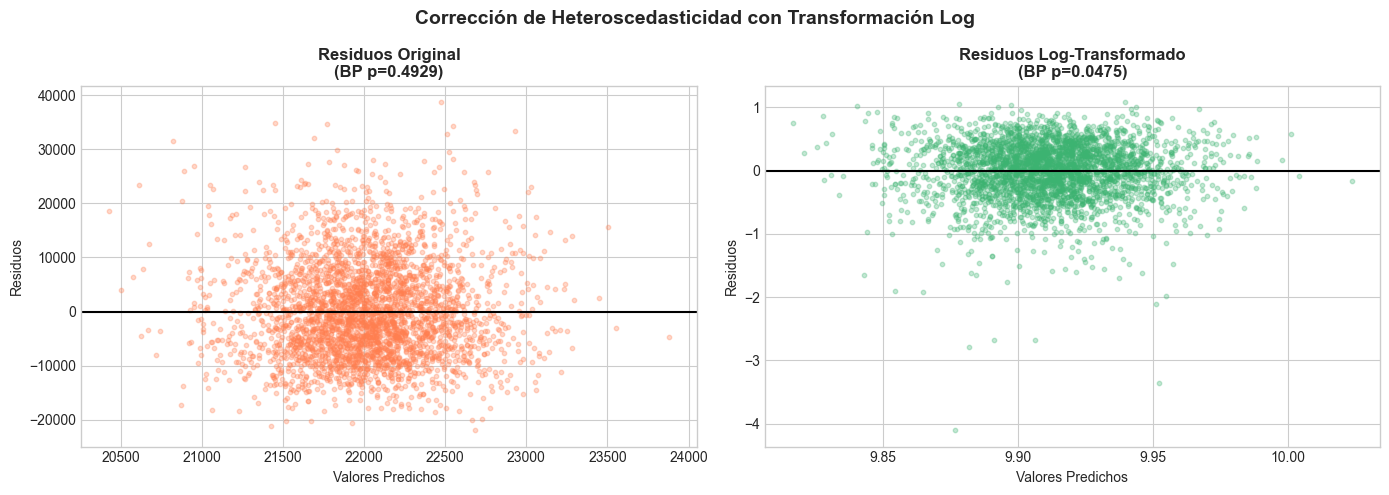

In [ ]:

# =============================================================================
# CONCEPTO: Corrección de heteroscedasticidad con transformación logarítmica
# -----------------------------------------------------------------------------
# Cuando se detecta heteroscedasticidad, una estrategia frecuente es
# transformar la variable respuesta para estabilizar la varianza.
#
# ESTRATEGIA: Log-transformación de la variable respuesta
#   Si Y ∼ distribución asimétrica con varianza creciente:
#   → log(Y) o log(1+Y) suele estabilizar la varianza (homocedasticidad).
#   → Esto ocurre porque la log "comprime" la escala de valores grandes
#     más que los pequeños, reduciendo la varianza de la cola derecha.
#
# np.log1p(df['Solids']):
#   → log(1 + Solids): más seguro que log(Solids) si hay ceros.
#   → Se guarda como nueva columna 'log_Solids' para uso posterior.
#
# COMPARACIÓN ANTES/DESPUÉS:
#   → Se ajustan dos modelos OLS con la misma predictora (Hardness):
#     Modelo original:     Hardness → Solids
#     Modelo log-trans.:   Hardness → log(Solids)
#   → Se aplica Breusch-Pagan a los residuos de ambos modelos.
#   → Si p_valor_log > p_valor_original → la transformación mejoró el supuesto.
#
# Gráfico residuos vs predichos:
#   → Panel izquierdo: residuos del modelo original (esperamos patrón embudo).
#   → Panel derecho: residuos del modelo log (esperamos nube aleatoria).
#   → El título incluye el p-valor de BP para cuantificar la mejora.
#
# CRITERIO DE USO: Aplicar log-transformación cuando:
#   1. La variable respuesta es estrictamente positiva.
#   2. El gráfico de residuos muestra patrón de embudo (varianza creciente).
#   3. El p-valor de Breusch-Pagan < 0.05 en el modelo original.
#   Advertencia: la interpretación de coeficientes cambia con la transformación
#   (un Δ de 1 unidad en X → Δ% en Y, no Δ absoluto).
# =============================================================================

# Ejemplo de corrección con transformación logarítmica
print("🔧 CORRECCIÓN CON TRANSFORMACIÓN LOGARÍTMICA")
print("=" * 50)

# Antes: modelo con Solids como respuesta
X_sm = sm.add_constant(df['Hardness'])
modelo_original = sm.OLS(df['Solids'], X_sm).fit()
_, pval_original, _, _ = het_breuschpagan(modelo_original.resid, X_sm)

# Después: modelo con log(Solids) como respuesta
df['log_Solids'] = np.log1p(df['Solids'])
modelo_log = sm.OLS(df['log_Solids'], X_sm).fit()
_, pval_log, _, _ = het_breuschpagan(modelo_log.resid, X_sm)

print(f"p-valor Breusch-Pagan (Original):   {pval_original:.6f}")
print(f"p-valor Breusch-Pagan (Log-trans):   {pval_log:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuos del modelo original — se espera patrón de embudo
axes[0].scatter(modelo_original.fittedvalues, modelo_original.resid, alpha=0.3, s=10, color='coral')
axes[0].axhline(0, color='black')
axes[0].set_title(f'Residuos Original\n(BP p={pval_original:.4f})', fontweight='bold')
axes[0].set_xlabel('Valores Predichos'); axes[0].set_ylabel('Residuos')

# Residuos del modelo log — se espera nube aleatoria
axes[1].scatter(modelo_log.fittedvalues, modelo_log.resid, alpha=0.3, s=10, color='mediumseagreen')
axes[1].axhline(0, color='black')
axes[1].set_title(f'Residuos Log-Transformado\n(BP p={pval_log:.4f})', fontweight='bold')
axes[1].set_xlabel('Valores Predichos'); axes[1].set_ylabel('Residuos')

plt.suptitle('Corrección de Heteroscedasticidad con Transformación Log', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
# 3. Multicolinealidad

## Definición

La **multicolinealidad** ocurre cuando dos o más variables predictoras están **altamente correlacionadas** entre sí. Esto causa:
- Inestabilidad en los coeficientes de regresión
- Dificultad para interpretar el efecto individual de cada variable
- Errores estándar inflados

## Detección: Factor de Inflación de Varianza (VIF)

$$VIF_i = \frac{1}{1 - R_i^2}$$

Donde $R_i^2$ es el R² de la regresión de la variable $X_i$ contra todas las demás variables.

| VIF | Interpretación |
|-----|----------------|
| 1 | Sin multicolinealidad |
| 1 - 5 | Moderada |
| 5 - 10 | Alta |
| > 10 | Muy alta (problemática) |

In [ ]:

# =============================================================================
# CONCEPTO: Factor de Inflación de Varianza (VIF) — detección de multicolinealidad
# -----------------------------------------------------------------------------
# La multicolinealidad ocurre cuando una predictora puede explicarse como
# combinación lineal de las demás. El VIF cuantifica cuánto se "infla" la
# varianza del coeficiente de regresión de esa variable por esta razón.
#
# FÓRMULA: VIF_i = 1 / (1 - R²_i)
#   → R²_i = coeficiente de determinación de la regresión de X_i contra
#     todas las DEMÁS variables predictoras.
#   → Si R²_i ≈ 1: X_i se predice casi perfectamente por las demás → VIF→∞.
#   → Si R²_i = 0: X_i es ortogonal a las demás → VIF = 1 (sin multicolinealidad).
#
# from statsmodels.stats.outliers_influence import variance_inflation_factor:
#   → variance_inflation_factor(X.values, col_index):
#     · X.values: matriz numpy de todas las predictoras (incluyendo constante).
#     · col_index: índice de la columna para la que se calcula el VIF.
#     · Devuelve el VIF escalar para esa variable.
#
# sm.add_constant(X_vif):
#   → El VIF se calcula sobre la matriz de diseño completa (con intercepto).
#   → Se usa [1:] al extraer las variables para excluir la constante del reporte.
#
# [variance_inflation_factor(X_vif.values, i+1) for i in range(len(cols_numericas))]:
#   → i+1 porque el índice 0 corresponde a la constante añadida por add_constant().
#
# Tabla de interpretación:
#   VIF < 5   → sin problema (verde)
#   VIF 5-10  → alta multicolinealidad → evaluar si conservar la variable
#   VIF > 10  → muy alta → considerar eliminar o combinar con PCA
#
# CRITERIO DE USO: Calcular VIF siempre antes de interpretar coeficientes
# de modelos de regresión múltiple. Un VIF > 10 sugiere que los coeficientes
# son inestables (pequeños cambios en los datos → grandes cambios en β).
# =============================================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

print("📐 FACTOR DE INFLACIÓN DE VARIANZA (VIF)")
print("=" * 55)

# Matriz de predictoras con constante para cálculo formal del VIF
X_vif = df[cols_numericas].copy()
X_vif = sm.add_constant(X_vif)   # agrega columna 'const' de unos

# Calcular VIF para cada variable (excluir la constante, índice 0)
vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif.columns[1:]
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(cols_numericas))]
vif_data['Interpretación'] = vif_data['VIF'].apply(
    lambda v: '✅ Sin problema' if v < 5 else ('⚠️ Alta' if v < 10 else '❌ Muy alta')
)
vif_data = vif_data.sort_values('VIF', ascending=False)

display(vif_data)

print(f"\n💡 Variables con VIF > 5: {vif_data[vif_data['VIF'] > 5]['Variable'].tolist()}")
print(f"   Variables con VIF > 10: {vif_data[vif_data['VIF'] > 10]['Variable'].tolist()}")


📐 FACTOR DE INFLACIÓN DE VARIANZA (VIF)


,Variable,VIF,Interpretación
2,Solids,1.039030,✅ Sin problema
4,Sulfate,1.035744,✅ Sin problema
1,Hardness,1.019982,✅ Sin problema
0,ph,1.016536,✅ Sin problema
3,Chloramines,1.008197,✅ Sin problema
6,Organic_carbon,1.004029,✅ Sin problema
8,Turbidity,1.002973,✅ Sin problema
5,Conductivity,1.002211,✅ Sin problema
7,Trihalomethanes,1.001979,✅ Sin problema



💡 Variables con VIF > 5: []
   Variables con VIF > 10: []


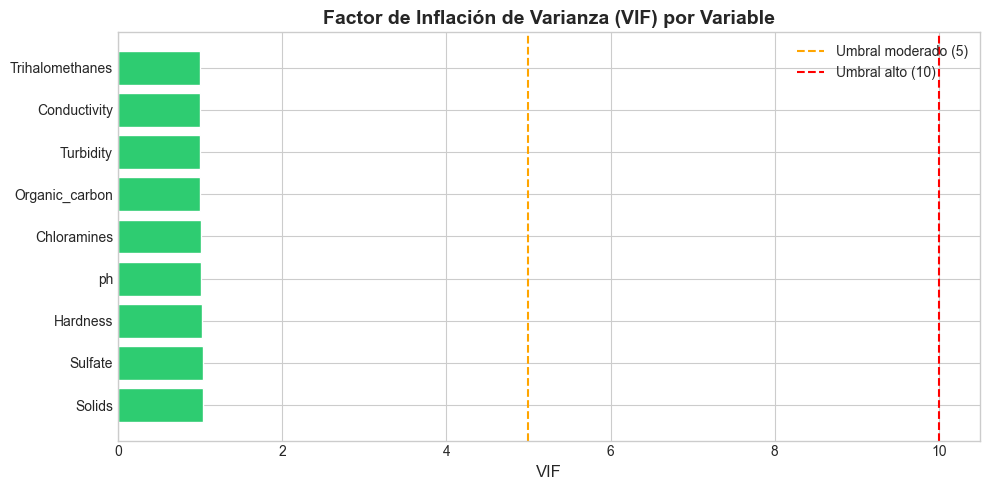

In [ ]:

# =============================================================================
# CONCEPTO: Visualización del VIF con umbrales de referencia
# -----------------------------------------------------------------------------
# El gráfico de barras horizontales con líneas de umbral comunica de forma
# clara e inmediata qué variables presentan problemas de multicolinealidad.
#
# colores_vif:
#   → Verde (#2ecc71):  VIF < 5 → sin problema.
#   → Naranja (#f39c12): VIF 5-10 → multicolinealidad moderada a alta.
#   → Rojo (#e74c3c):   VIF > 10 → multicolinealidad muy alta.
#   → El color de cada barra se asigna dinámicamente según el valor de VIF.
#
# plt.barh(variables, valores):
#   → Barras horizontales: más legibles cuando los nombres de variables
#     son largos und deben leerse de izquierda a derecha.
#
# plt.axvline(x=5, color='orange', linestyle='--'):
#   → Línea vertical de umbral moderado en x=5.
#
# plt.axvline(x=10, color='red', linestyle='--'):
#   → Línea vertical de umbral crítico en x=10.
#
# INTERPRETACIÓN VISUAL:
#   → Barras que no alcanzan la línea naranja = sin problema.
#   → Barras entre las dos líneas = evaluar si la variable es necesaria.
#   → Barras más allá de la línea roja = considerar eliminar, combinar
#     con otra variable, o usar técnicas de reducción de dimensionalidad (PCA).
#
# CRITERIO DE USO: Incluir este gráfico en el reporte de selección de
# features antes de construir el modelo de regresión múltiple. Es más
# accesible para audiencias no técnicas que la tabla numérica del VIF.
# =============================================================================

# Visualización del VIF con umbrales de referencia
plt.figure(figsize=(10, 5))
colores_vif = ['#2ecc71' if v < 5 else '#f39c12' if v < 10 else '#e74c3c' for v in vif_data['VIF']]
plt.barh(vif_data['Variable'], vif_data['VIF'], color=colores_vif, edgecolor='white')
plt.axvline(x=5, color='orange', linestyle='--', label='Umbral moderado (5)')
plt.axvline(x=10, color='red', linestyle='--', label='Umbral alto (10)')
plt.xlabel('VIF', fontsize=12)
plt.title('Factor de Inflación de Varianza (VIF) por Variable', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:

# =============================================================================
# CONCEPTO: Identificación de los pares de variables más correlacionados
# -----------------------------------------------------------------------------
# Complementa el VIF con un ranking directo de los pares con mayor correlación
# absoluta, que son las relaciones que más contribuyen a la multicolinealidad.
#
# corr_abs = corr_pearson.abs():
#   → Toma el valor absoluto de toda la matriz de correlación.
#   → Unifica correlaciones positivas y negativas en una escala de 0 a 1.
#
# np.fill_diagonal(corr_abs.values, 0):
#   → Coloca 0 en la diagonal principal (autocorrelaciones de 1.0).
#   → Sin esto, la diagonal dominaría el ranking y no sería informativa.
#   → .values accede al array numpy subyacente para modificarlo in-place.
#
# Loop triangular (j > i):
#   → Itera solo sobre el triángulo superior de la matriz (evita duplicados).
#   → Para n variables hay n*(n-1)/2 pares únicos.
#
# .sort_values('|Correlación|', ascending=False):
#   → Ordena de mayor a menor correlación absoluta.
#   → Los pares al tope son los candidatos a causar multicolinealidad.
#
# RELACIÓN VIF ↔ CORRELACIÓN MATRICIAL:
#   Un VIF alto generalmente se debe a una o más correlaciones altas
#   entre esa variable y las demás. Identificar los pares más correlacionados
#   ayuda a decidir qué variable conservar cuando se detecta multicolinealidad.
#   Regla práctica: conservar la que tenga mayor interpretabilidad o
#   correlación con la variable objetivo.
#
# CRITERIO DE USO: Revisar esta tabla cuando VIF > 5 en alguna variable.
# Los pares con |r| > 0.8 son candidatos directos a causar el VIF elevado.
# =============================================================================

# Detección visual de multicolinealidad con scatter matrix
corr_abs = corr_pearson.abs()
np.fill_diagonal(corr_abs.values, 0)    # eliminar autocorrelaciones (diagonal)

print("🔗 TOP 5 PARES DE VARIABLES MÁS CORRELACIONADOS")
print("=" * 55)

pares_corr = []
for i in range(len(corr_abs.columns)):
    for j in range(i+1, len(corr_abs.columns)):    # j > i: evita duplicados
        pares_corr.append({
            'Variable 1': corr_abs.columns[i],
            'Variable 2': corr_abs.columns[j],
            '|Correlación|': corr_abs.iloc[i, j]
        })

df_pares = pd.DataFrame(pares_corr).sort_values('|Correlación|', ascending=False)
display(df_pares.head(10))


🔗 TOP 5 PARES DE VARIABLES MÁS CORRELACIONADOS


,Variable 1,Variable 2,|Correlación|
16,Solids,Sulfate,0.149747
10,Hardness,Sulfate,0.092833
1,ph,Solids,0.082004
0,ph,Hardness,0.075760
15,Solids,Chloramines,0.070148
8,Hardness,Solids,0.046899
5,ph,Organic_carbon,0.040240
7,ph,Turbidity,0.036107
2,ph,Chloramines,0.031741
9,Hardness,Chloramines,0.030054


---
# 4. Definición de la Pregunta de Investigación

## ¿Qué es una Pregunta de Investigación?

Es una pregunta **clara, específica y medible** que guía el análisis de datos. Debe ser:
- **Específica**: Enfocada en un aspecto concreto
- **Medible**: Puede responderse con datos cuantitativos
- **Relevante**: Tiene importancia práctica o científica
- **Factible**: Puede responderse con los datos disponibles

## Preguntas de Investigación para nuestro Dataset

Basándonos en nuestro análisis exploratorio y de correlación, formulamos las siguientes preguntas:

### Pregunta Principal:
> **¿Qué variables fisicoquímicas influyen significativamente en la potabilidad del agua?**

### Preguntas Secundarias:
1. ¿Existe una diferencia significativa en el nivel de pH entre muestras de agua potable y no potable?
2. ¿La dureza del agua está relacionada linealmente con la concentración de sulfatos?
3. ¿La turbidez es un predictor significativo de la potabilidad del agua?

---
# 5. Formulación y Pruebas de Hipótesis

## ¿Qué es una Hipótesis?

- **Hipótesis Nula (H₀)**: Afirmación de que **no hay efecto** o diferencia significativa (lo que queremos refutar)
- **Hipótesis Alternativa (H₁)**: Afirmación de que **sí hay un efecto** o diferencia significativa (lo que queremos demostrar)

### Criterio de decisión:
- Si **p-valor < α** (generalmente 0.05): Rechazamos H₀ → Hay evidencia estadística
- Si **p-valor ≥ α**: No rechazamos H₀ → No hay suficiente evidencia

### Nivel de significancia (α):
- α = 0.05 (5%) es el más común en ciencias
- α = 0.01 (1%) para pruebas más rigurosas

In [ ]:

# =============================================================================
# CONCEPTO: Prueba t de Student para muestras independientes
# -----------------------------------------------------------------------------
# La prueba t de Student compara las medias de DOS grupos independientes
# para determinar si la diferencia observada es estadísticamente significativa
# o podría deberse al azar.
#
# HIPÓTESIS FORMULADAS:
#   H₀: μ_potable = μ_no_potable  (no hay diferencia en el pH promedio)
#   H₁: μ_potable ≠ μ_no_potable  (hay diferencia significativa)
#   → Esta es una prueba BILATERAL (dos colas): se detecta diferencia en
#     cualquier dirección (mayor o menor).
#
# stats.ttest_ind(grupo1, grupo2):
#   → Prueba t de Welch (varianzas no iguales, más robusta que la t clásica).
#   → Devuelve: (t_statistic, p_valor)
#       t_statistic > 0: media del primer grupo mayor.
#       t_statistic < 0: media del segundo grupo mayor.
#       |t| grande → diferencia grande relativa a la variabilidad interna.
#   → p_valor: probabilidad de observar una diferencia al menos tan grande
#     si H₀ fuera verdad (bajo la hipótesis nula).
#
# alpha = 0.05:
#   → Nivel de significancia convencional (5%).
#   → Si p < 0.05 → evidencia suficiente para rechazar H₀.
#   → Si p ≥ 0.05 → no hay evidencia suficiente (no se puede probar H₁).
#
# SUPUESTOS DE LA PRUEBA T:
#   ✔ Las observaciones son independientes entre sí.
#   ✔ Las poblaciones tienen distribución aproximadamente normal
#     (o n suficientemente grande por el Teorema Central del Límite).
#   ✔ Las varianzas pueden ser diferentes entre grupos (variante de Welch).
#
# CRITERIO DE USO: Usar t-test de dos muestras cuando se quiere comparar
# una variable continua entre dos grupos dicotómicos (binario, categoría).
# Para más de 2 grupos, usar ANOVA.
# =============================================================================

alpha = 0.05  # Nivel de significancia convencional

print("🧪 HIPÓTESIS 1: Diferencia de pH por Potabilidad")
print("=" * 55)
print("H₀: No hay diferencia significativa en el pH entre agua potable y no potable")
print("H₁: Hay una diferencia significativa en el pH entre ambos grupos")
print()

# Separar grupos según la variable Potability
ph_potable    = df[df['Potability'] == 1]['ph']
ph_no_potable = df[df['Potability'] == 0]['ph']

# Prueba t de Student (variante de Welch) para muestras independientes
t_stat, p_valor = stats.ttest_ind(ph_potable, ph_no_potable)

print(f"  Media pH Potable:    {ph_potable.mean():.4f}")
print(f"  Media pH No Potable: {ph_no_potable.mean():.4f}")
print(f"  Estadístico t:       {t_stat:.4f}")
print(f"  p-valor:             {p_valor:.6f}")
print(f"\n  Decisión: {'❌ RECHAZAR H₀ → Hay diferencia significativa' if p_valor < alpha else '✅ NO RECHAZAR H₀ → No hay evidencia de diferencia'}")


🧪 HIPÓTESIS 1: Diferencia de pH por Potabilidad
H₀: No hay diferencia significativa en el pH entre agua potable y no potable
H₁: Hay una diferencia significativa en el pH entre ambos grupos

  Media pH Potable:    7.0687
  Media pH No Potable: 7.0777
  Estadístico t:       -0.1725
  p-valor:             0.863091

  Decisión: ✅ NO RECHAZAR H₀ → No hay evidencia de diferencia


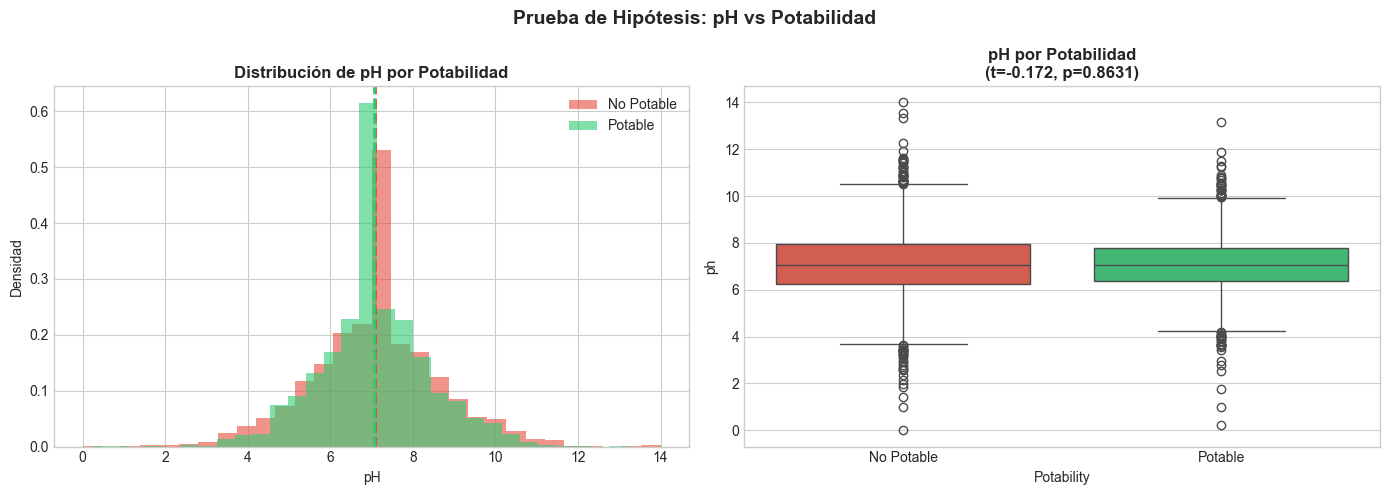

In [ ]:

# =============================================================================
# CONCEPTO: Visualización de la Hipótesis 1 — distribuciones y boxplot
# -----------------------------------------------------------------------------
# La visualización complementa la prueba t mostrando la distribución real
# de los datos en ambos grupos, lo que permite evaluar si la diferencia
# es prácticamente relevante además de estadísticamente significativa.
#
# GRÁFICO IZQUIERDO — Histogramas superpuestos con densidad:
#   alpha=0.6: semitransparencia para ver la superposición de ambas distribuciones.
#   density=True: normaliza las frecuencias a densidad de probabilidad
#     → permite comparar grupos con diferentes tamaños.
#   axvline(media): línea vertical en la media de cada grupo para visualizar
#     el desplazamiento horizontal entre distribuciones.
#   → Si las distribuciones se superponen mucho, la diferencia estadística
#     puede ser significativa pero con poco efecto práctico (efecto pequeño).
#
# GRÁFICO DERECHO — Boxplot por grupo:
#   sns.boxplot(data, x='Potability', y='ph'):
#     → Muestra mediana, cuartiles, bigotes y outliers para cada grupo.
#     → Permite ver si hay diferencia en la MEDIANA (no solo en la media).
#   set_xticklabels(['No Potable', 'Potable']): etiquetas descriptivas.
#   Título con t y p en el encabezado: permite leer la conclusión directamente.
#
# IMPORTANCIA DE LA VISUALIZACIÓN:
#   Una prueba t puede ser significativa (p < 0.05) incluso con diferencias
#   muy pequeñas si n es grande. El gráfico permite evaluar si la diferencia
#   es también PRÁCTICAMENTE relevante (tamaño del efecto visible).
#
# CRITERIO DE USO: Siempre combinar la prueba estadística con la visualización.
# La estadística da el "¿es real?" y el gráfico da el "¿es importante?".
# =============================================================================

# Visualización de la Hipótesis 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramas superpuestos con densidad normalizada
axes[0].hist(ph_no_potable, bins=30, alpha=0.6, color='#e74c3c', label='No Potable', density=True)
axes[0].hist(ph_potable, bins=30, alpha=0.6, color='#2ecc71', label='Potable', density=True)
axes[0].axvline(ph_no_potable.mean(), color='#e74c3c', linestyle='--', linewidth=2)
axes[0].axvline(ph_potable.mean(), color='#2ecc71', linestyle='--', linewidth=2)
axes[0].set_xlabel('pH')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de pH por Potabilidad', fontweight='bold')
axes[0].legend()

# Boxplot: mediana, IQR, outliers por grupo
sns.boxplot(data=df, x='Potability', y='ph', palette=['#e74c3c', '#2ecc71'], ax=axes[1])
axes[1].set_xticklabels(['No Potable', 'Potable'])
axes[1].set_title(f'pH por Potabilidad\n(t={t_stat:.3f}, p={p_valor:.4f})', fontweight='bold')

plt.suptitle('Prueba de Hipótesis: pH vs Potabilidad', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:

# =============================================================================
# CONCEPTO: Prueba de hipótesis sobre correlación (Pearson con p-valor)
# -----------------------------------------------------------------------------
# La correlación de Pearson puede evaluarse formalmente con una prueba de
# hipótesis para determinar si el coeficiente r observado es estadísticamente
# diferente de cero (o sea, si la correlación es "real" y no debida al azar).
#
# HIPÓTESIS FORMULADAS:
#   H₀: ρ = 0  (no existe correlación lineal entre Dureza y Sulfatos)
#   H₁: ρ ≠ 0  (existe correlación lineal significativa)
#   → Prueba BILATERAL (dos colas): se detecta correlación positiva o negativa.
#
# pearsonr(x, y) → (r, p_valor):
#   → r: coeficiente de correlación de Pearson (-1 a +1).
#   → p_valor: probabilidad de observar |r| ≥ |r_observado| si ρ=0
#     bajo la distribución de muestreo.
#   → Se basa en el estadístico t = r√(n-2)/√(1-r²) con n-2 grados de libertad.
#
# DIFERENCIA ENTRE COEFICIENTE Y PRUEBA:
#   El coeficiente r dice el TAMAÑO de la relación (cuán fuerte es).
#   El p-valor dice si la relación es REAL (podría no serlo por azar).
#   Con n grande, incluso r muy pequeño puede ser significativo (p < 0.05).
#   → Por eso importa reportar AMBOS: r (efecto) y p (significancia).
#
# CRITERIO DE USO: Usar pearsonr() en lugar de .corr() cuando se necesita
# el p-valor junto con el coeficiente para una prueba formal de hipótesis
# sobre la correlación entre dos variables específicas.
# =============================================================================

print("🧪 HIPÓTESIS 2: Correlación entre Dureza y Sulfatos")
print("=" * 55)
print("H₀: No existe correlación significativa entre Dureza y Sulfatos (ρ = 0)")
print("H₁: Existe una correlación significativa entre Dureza y Sulfatos (ρ ≠ 0)")
print()

r, p_valor_corr = pearsonr(df['Hardness'], df['Sulfate'])

print(f"  Coeficiente de Pearson (r): {r:.4f}")
print(f"  p-valor:                    {p_valor_corr:.6f}")
print(f"\n  Decisión: {'❌ RECHAZAR H₀ → Correlación significativa' if p_valor_corr < alpha else '✅ NO RECHAZAR H₀ → No hay correlación significativa'}")


🧪 HIPÓTESIS 2: Correlación entre Dureza y Sulfatos
H₀: No existe correlación significativa entre Dureza y Sulfatos (ρ = 0)
H₁: Existe una correlación significativa entre Dureza y Sulfatos (ρ ≠ 0)

  Coeficiente de Pearson (r): -0.0928
  p-valor:                    0.000000

  Decisión: ❌ RECHAZAR H₀ → Correlación significativa


In [ ]:

# =============================================================================
# CONCEPTO: ANOVA de un factor — comparación de medias entre dos grupos
# -----------------------------------------------------------------------------
# El ANOVA (Analysis of Variance) prueba si las medias de dos o más grupos
# son iguales. Con solo dos grupos equivale a la prueba t, pero es más
# general y escalable a múltiples grupos.
#
# HIPÓTESIS:
#   H₀: μ_potable = μ_no_potable  (las medias son iguales en ambos grupos)
#   H₁: Al menos una media difiere
#
# stats.f_oneway(grupo0, grupo1) → (F_stat, p_valor):
#   → F_stat: cociente entre la varianza ENTRE grupos y la varianza DENTRO
#     de grupos. F grande → diferencia entre grupos >> variabilidad interna.
#   → p_valor: probabilidad bajo H₀ de observar un F tan grande o mayor.
#   → p < 0.05: rechazo H₀ → hay diferencia estadísticamente significativa.
#
# VENTAJA DEL BARRIDO COMPLETO:
#   Al aplicar ANOVA a TODAS las variables predictoras en paralelo:
#   → Se identifican cuáles tienen potencial discriminatorio real entre
#     los grupos potable/no potable.
#   → Sirve como ranking de "utilidad" de cada feature para el modelo.
#
# resultados_anova lista → pd.DataFrame:
#   → Almacena F, p y resultado para cada variable en formato tabular.
#   → .sort_values('p-valor'): las variables más significativas primero.
#
# variables_sig:
#   → Lista de predictoras con diferencias estadísticamente significativas.
#   → Candidatas principales a incluir en el modelo de regresión/clasificación.
#
# LIMITACIÓN: ANOVA asume normalidad e igualdad de varianzas.
# Con n grande (≥30 por grupo), el t-test/ANOVA es robusto a violaciones.
# Alternativa no paramétrica: Kruskal-Wallis.
#
# CRITERIO DE USO: El ANOVA combinado con correlación y VIF forma la triada
# básica del análisis de features antes de construir un modelo predictivo.
# =============================================================================

print("🧪 HIPÓTESIS 3: ANOVA — Diferencias por Potabilidad en todas las variables")
print("=" * 65)
print("H₀: Las medias de ambos grupos (potable vs no potable) son iguales")
print("H₁: Al menos una media es diferente")
print()

resultados_anova = []

for col in cols_numericas:
    grupo_0 = df[df['Potability'] == 0][col]
    grupo_1 = df[df['Potability'] == 1][col]
    f_stat, p_val = stats.f_oneway(grupo_0, grupo_1)
    resultados_anova.append({
        'Variable': col,
        'F-statistic': f_stat,
        'p-valor': p_val,
        'Significativo': '✅ Sí' if p_val < alpha else '❌ No'
    })

df_anova = pd.DataFrame(resultados_anova).sort_values('p-valor')
display(df_anova)

variables_sig = df_anova[df_anova['p-valor'] < alpha]['Variable'].tolist()
print(f"\n📋 Variables con diferencia significativa (p < {alpha}): {variables_sig if variables_sig else 'Ninguna'}")


🧪 HIPÓTESIS 3: ANOVA — Diferencias por Potabilidad en todas las variables
H₀: Las medias de ambos grupos (potable vs no potable) son iguales
H₁: Al menos una media es diferente



,Variable,F-statistic,p-valor,Significativo
2,Solids,3.732062,0.053464,❌ No
6,Organic_carbon,2.949523,0.085997,❌ No
3,Chloramines,1.852296,0.173610,❌ No
4,Sulfate,1.373307,0.241330,❌ No
1,Hardness,0.626928,0.428542,❌ No
5,Conductivity,0.216326,0.641885,❌ No
7,Trihalomethanes,0.155277,0.693568,❌ No
0,ph,0.029741,0.863091,❌ No
8,Turbidity,0.008180,0.927939,❌ No



📋 Variables con diferencia significativa (p < 0.05): Ninguna


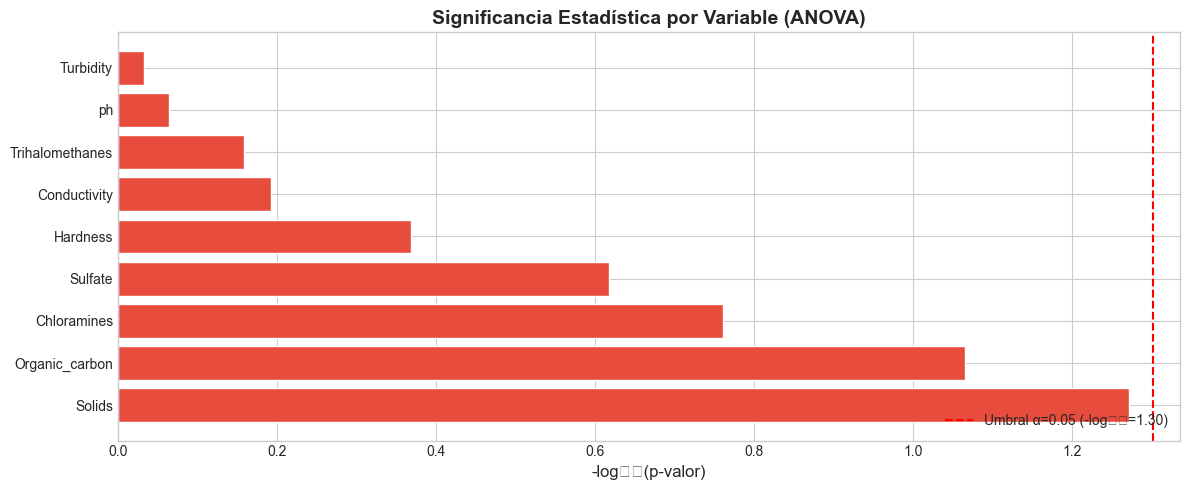

💡 Barras VERDES (a la derecha de la línea roja) = Variables con diferencia significativa


In [ ]:

# =============================================================================
# CONCEPTO: Visualización de significancia estadística con -log₁₀(p-valor)
# -----------------------------------------------------------------------------
# Graficar -log₁₀(p-valor) en lugar del p-valor directamente tiene varias
# ventajas para comunicar resultados de pruebas de hipótesis múltiples.
#
# POR QUÉ -log₁₀(p-valor)?
#   → Los p-valores pueden ser muy pequeños (p=0.000001) → difíciles de
#     comparar visualmente en una escala lineal.
#   → -log₁₀(p): transforma p-valores pequeños en números grandes y
#     fácilmente comparables:
#       p = 0.05    → -log₁₀(0.05) ≈ 1.30
#       p = 0.01    → -log₁₀(0.01) = 2.00
#       p = 0.001   → -log₁₀(0.001) = 3.00
#       p = 0.0001  → -log₁₀(0.0001) = 4.00
#   → Las barras MÁS LARGAS corresponden a los p-valores MÁS SIGNIFICATIVOS.
#
# -np.log10(df_anova['p-valor']):
#   → Aplica la transformación a toda la columna de p-valores.
#   → El signo negativo convierte log(p<1) que sería negativo en positivo.
#
# Umbral en x = -log₁₀(0.05) = 1.301:
#   → axvline(x=-np.log10(alpha)): línea vertical en el umbral de significancia.
#   → Variables a la DERECHA de esta línea → p < 0.05 → rechazan H₀.
#
# colores_pval:
#   → Verde: variables con p < alpha (rechazan H₀, diferencia significativa).
#   → Rojo: variables sin diferencia significativa.
#
# CRITERIO DE USO: Esta representación es estándar en estudios de asociación
# genómica (Manhattan plots), análisis proteómicos y cualquier análisis
# con múltiples pruebas de hipótesis simultáneas donde se quiere identificar
# qué variables son más significativas de un vistazo.
# =============================================================================

# Resumen visual de todas las pruebas de hipótesis (ANOVA)
plt.figure(figsize=(12, 5))

colores_pval = ['#2ecc71' if p < alpha else '#e74c3c' for p in df_anova['p-valor']]
plt.barh(df_anova['Variable'], -np.log10(df_anova['p-valor']), color=colores_pval, edgecolor='white')
plt.axvline(x=-np.log10(alpha), color='red', linestyle='--',
            label=f'Umbral α={alpha} (-log₁₀={-np.log10(alpha):.2f})')
plt.xlabel('-log₁₀(p-valor)', fontsize=12)
plt.title('Significancia Estadística por Variable (ANOVA)',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("💡 Barras VERDES (a la derecha de la línea roja) = Variables con diferencia significativa")


---
## Conclusiones

En esta semana aprendimos:

1. **Correlación**: Analizamos relaciones lineales (Pearson) y monótonas (Spearman, Kendall) entre las variables de calidad del agua. Encontramos que las correlaciones son generalmente débiles.

2. **Homoscedasticidad/Heteroscedasticidad**: Evaluamos la constancia de la varianza de los residuos usando pruebas formales (Breusch-Pagan, Goldfeld-Quandt) y gráficos de residuos. Aplicamos transformaciones logarítmicas como estrategia de corrección.

3. **Multicolinealidad**: Calculamos el VIF para detectar variables predictoras altamente correlacionadas entre sí. Identificamos las variables que podrían causar problemas en modelos de regresión.

4. **Preguntas de investigación**: Formulamos preguntas claras y medibles sobre las relaciones entre variables fisicoquímicas y potabilidad.

5. **Hipótesis**: Construimos y probamos hipótesis estadísticas usando t-test, correlación de Pearson y ANOVA. Determinamos qué variables presentan diferencias significativas entre agua potable y no potable.

**Próxima semana:** Construiremos modelos de Regresión Lineal Simple y Múltiple para predecir variables de calidad del agua, aplicando todos los conocimientos adquiridos.